# MINI PROJECT 8 MARKET BASKET ANALYSIS

##### Yumita

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

### 1. Import Data

In [2]:
df = pd.read_csv("Groceries_dataset.csv") 
df

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk
...,...,...,...
38760,4471,08-10-2014,sliced cheese
38761,2022,23-02-2014,candy
38762,1097,16-04-2014,cake bar
38763,1510,03-12-2014,fruit/vegetable juice


### 2. Data Exploration

##### 1. Cek info dasar dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Member_number    38765 non-null  int64 
 1   Date             38765 non-null  object
 2   itemDescription  38765 non-null  object
dtypes: int64(1), object(2)
memory usage: 908.7+ KB


In [4]:
df.shape

(38765, 3)

INTERPRETASI :
- Dataset market basket analysis terdiri dari 38.765 baris data dan 3 kolom

##### 2. Cek nilai data

In [5]:
df.describe().round(2)

,Member_number
count,38765.00
mean,3003.64
std,1153.61
min,1000.00
25%,2002.00
50%,3005.00
75%,4007.00
max,5000.00


##### 3. Mengecek missing value dataset

In [6]:
df.isnull().sum()

Member_number      0
Date               0
itemDescription    0
dtype: int64

INTERPRETASI :
- Dari ketiga kolom dataset tidak terdapat missing value 

##### 4. Cek type data

In [7]:
df.dtypes

Member_number       int64
Date               object
itemDescription    object
dtype: object

INTERPRETASI :
- Pada ketiga kolom, terdapat 1 kolom yaitu kolom "Date" yang belum sesuai type datanya

##### 5. Cek nilai duplicate dataset

In [8]:
duplicate = df.duplicated().sum()
print(duplicate)

759


In [9]:
df["Member_number"].nunique()

3898

In [10]:
df["Date"].nunique()

728

In [11]:
df["itemDescription"].nunique()

167

##### 6. Cek typo pada kolom yang berupa kategorikal

In [12]:
# Proporsi data kategori untuk di cek typo nya
cat_cols = ['itemDescription']

for col in cat_cols :
    print(f'\nDistribusi {col}')
    print(df[col].value_counts(dropna=False))


Distribusi itemDescription
itemDescription
whole milk               2502
other vegetables         1898
rolls/buns               1716
soda                     1514
yogurt                   1334
                         ... 
rubbing alcohol             5
bags                        4
baby cosmetics              3
kitchen utensil             1
preservation products       1
Name: count, Length: 167, dtype: int64


##### 7. Mengecek kolom "Date" dataset awal

In [13]:
df['Date'].min()

'01-01-2014'

In [14]:
df['Date'].max()

'31-10-2015'

INTERPRETASI :
- Dataset ini catatan data selama 21 bulan, dicatat dari tanggal 1 Januari 2014 sampai dengan 31 Oktober 2015

#### 8. Mengecek outlier dataset awal

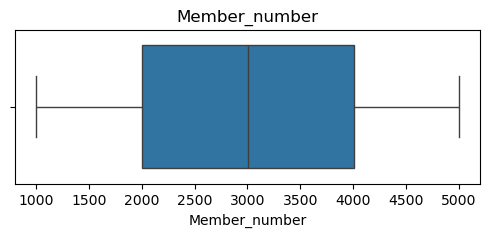

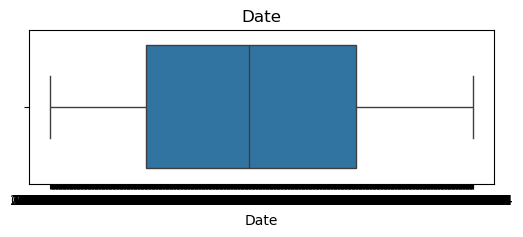

In [15]:
num_cols=[
'Member_number', 'Date']

for col in num_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

- Karena data integernya hanya data urutan member, tidak ada nilai integer yang harus dianalisis outliernya maka tidak ada pengecekan nilai outlier pada dataset tersebut

### 3. Data Cleaning

In [16]:
df_clean = df.copy()

##### 1. Mengubah type data

In [17]:
df_clean['Date'] = pd.to_datetime(df_clean['Date'], dayfirst=True)

In [18]:
df_clean.dtypes

Member_number               int64
Date               datetime64[ns]
itemDescription            object
dtype: object

##### 2. Memperbaiki penulisan nama judul kolom

In [19]:
df_clean = df_clean.rename(columns={
    'Member_number': 'Member_number',
    'Date': 'Date',
    'itemDescription': 'Item_description'})

In [20]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Member_number     38765 non-null  int64         
 1   Date              38765 non-null  datetime64[ns]
 2   Item_description  38765 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 908.7+ KB


### 4. Data Manipulation

##### FEATURING ENGINEERING

##### 1. Membuat kolom tahun

In [21]:
df_clean['Year'] = df_clean['Date'].dt.year

- Kolom tahun ini digunakan untuk menganalisis tren tahunan dari dataset perusahaan

##### 2. Membuat kolom bulan

In [22]:
df_clean['Month'] = df_clean['Date'].dt.month_name()

- Kolom bulan untuk menganalisis tren bulanan dari penjualan 

##### 3. Membuat kolom nomor bulan

In [23]:
df_clean['Month_num'] = df_clean['Date'].dt.month

- Untuk digunakan saat sorting di tableu

##### 4. Kolom Quarter

In [24]:
df_clean['Quarter'] = df_clean['Date'].dt.quarter

##### 5. Kolom nama hari 

In [25]:
df_clean['Day_name'] = df_clean['Date'].dt.day_name()

- Digunakan untuk melihat tren hari paling ramai transaksi penjualan

##### 6. Kolom transaction ID

In [26]:
df_clean['Transaction_ID'] = (
    df_clean['Member_number'].astype(str)
    + '_'
    + df_clean['Date'].astype(str)
)

- Kolom ini digunakan untuk MBA

##### 7. Kolom Basket Size

In [27]:
# Jumlah item dalam satu transaksi
basket_size = (
    df_clean.groupby('Transaction_ID')
    .size()
    .reset_index(name='Basket_size')
)

In [28]:
# Menggabungkan kembali
df_clean = df_clean.merge(
    basket_size,
    on='Transaction_ID',
    how='left'
)

In [29]:
df_clean.head()

,Member_number,Date,Item_description,Year,Month,Month_num,Quarter,Day_name,Transaction_ID,Basket_size
0,1808,2015-07-21,tropical fruit,2015,July,7,3,Tuesday,1808_2015-07-21,3
1,2552,2015-01-05,whole milk,2015,January,1,1,Monday,2552_2015-01-05,3
2,2300,2015-09-19,pip fruit,2015,September,9,3,Saturday,2300_2015-09-19,3
3,1187,2015-12-12,other vegetables,2015,December,12,4,Saturday,1187_2015-12-12,3
4,3037,2015-02-01,whole milk,2015,February,2,1,Sunday,3037_2015-02-01,3


In [31]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Member_number     38765 non-null  int64         
 1   Date              38765 non-null  datetime64[ns]
 2   Item_description  38765 non-null  object        
 3   Year              38765 non-null  int32         
 4   Month             38765 non-null  object        
 5   Month_num         38765 non-null  int32         
 6   Quarter           38765 non-null  int32         
 7   Day_name          38765 non-null  object        
 8   Transaction_ID    38765 non-null  object        
 9   Basket_size       38765 non-null  int64         
dtypes: datetime64[ns](1), int32(3), int64(2), object(4)
memory usage: 2.5+ MB


In [32]:
df_clean['Transaction_ID'].nunique()

14963

In [35]:
df_clean['Basket_size'].mean().round(2)

np.float64(3.07)

INTERPRETASI :
- Rata-rata pelanggan membeli sebanyak 3 item dalam satu kali transaksi

### 5. Exploratory Data Analysis (EDA)

##### UNIVARIATE

##### 1. Top 10 Produk terlaris

In [36]:
top_product = (
    df_clean['Item_description']
    .value_counts()
    .head(10)
)

top_product

Item_description
whole milk          2502
other vegetables    1898
rolls/buns          1716
soda                1514
yogurt              1334
root vegetables     1071
tropical fruit      1032
bottled water        933
sausage              924
citrus fruit         812
Name: count, dtype: int64

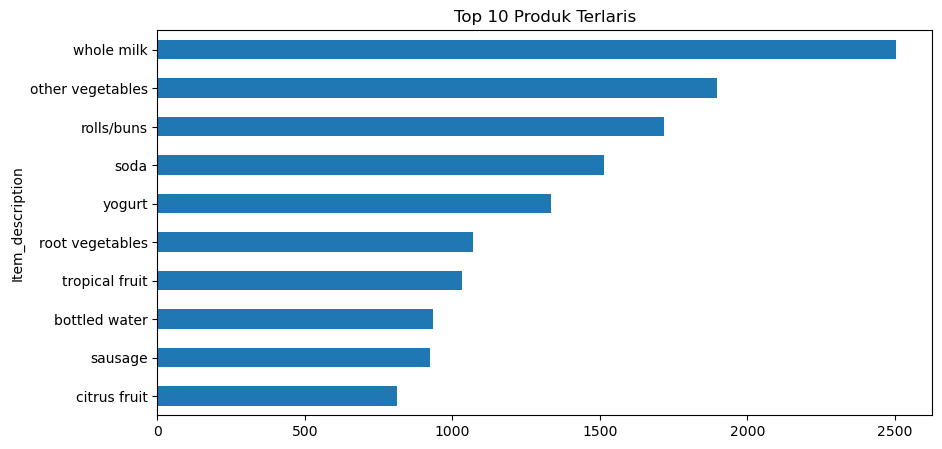

In [37]:
plt.figure(figsize=(10,5))

top_product.sort_values().plot(
    kind='barh'
)

plt.title('Top 10 Produk Terlaris')
plt.show()

INTERPRETASI :
- Whole milk menjadi produk dengan frekuensi pembelian tertinggi sehingga menjadi produk utama dalam supermarket

##### 2. Bottom 10 Produk

In [39]:
bottom_product = (
    df_clean['Item_description']
    .value_counts()
    .tail(10)
)

bottom_product

Item_description
whisky                   8
salad dressing           6
frozen chicken           5
make up remover          5
toilet cleaner           5
rubbing alcohol          5
bags                     4
baby cosmetics           3
kitchen utensil          1
preservation products    1
Name: count, dtype: int64

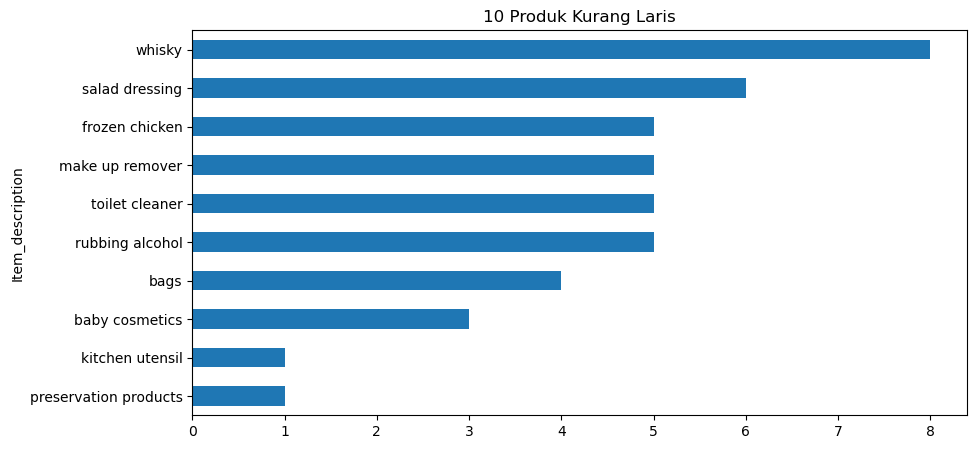

In [41]:
plt.figure(figsize=(10,5))

bottom_product.sort_values().plot(
    kind='barh'
)

plt.title('10 Produk Kurang Laris')
plt.show()

INTERPRETASI :
- Produk yang jarang dibeli bisa menjadi kandidat evaluasi promosi

##### 3. Distribusi Basket Size

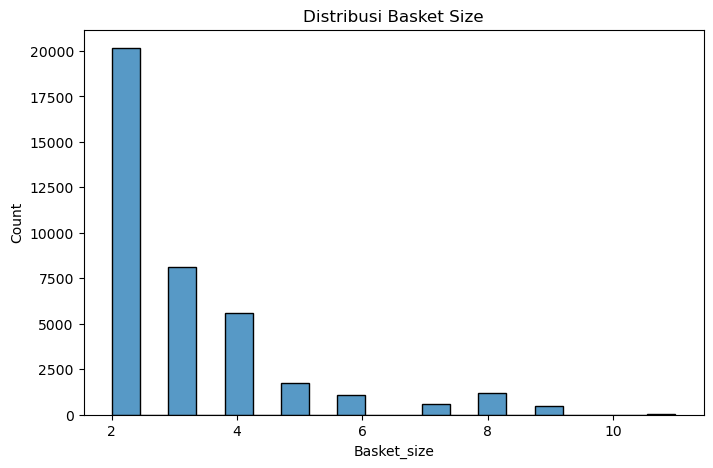

In [44]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_clean['Basket_size'],
    bins=20
)

plt.title('Distribusi Basket Size')
plt.show()

Insight :
- Mayoritas pelanggan membeli sekitar 2-5 item produk dalam sekali transaksi

##### 4. Distribusi hari transaksi

In [54]:
day_freq = (
    df_clean['Day_name']
    .value_counts()
    .reset_index()
)

day_freq.columns=['Day','Transactions']

<Axes: xlabel='Day', ylabel='Transactions'>

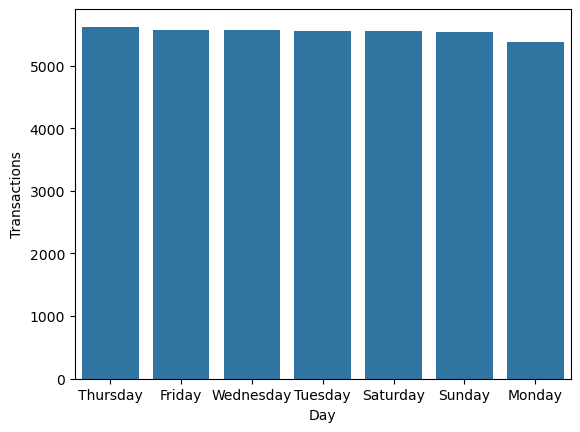

In [55]:
sns.barplot(
    data=day_freq,
    x='Day',
    y='Transactions'
)

Insight :
- Aktivitas belanja tertinggi 

##### BIVARIATE

##### 1. Tren Jumlah Transaksi Bulanan

In [62]:
monthly_tren = (
    df_clean.groupby(
        ['Year','Month_num','Month']
    )['Transaction_ID']
    .nunique()
    .reset_index()
)

monthly_tren.head()

,Year,Month_num,Month,Transaction_ID
0,2014,1,January,665
1,2014,2,February,623
2,2014,3,March,608
3,2014,4,April,678
4,2014,5,May,711


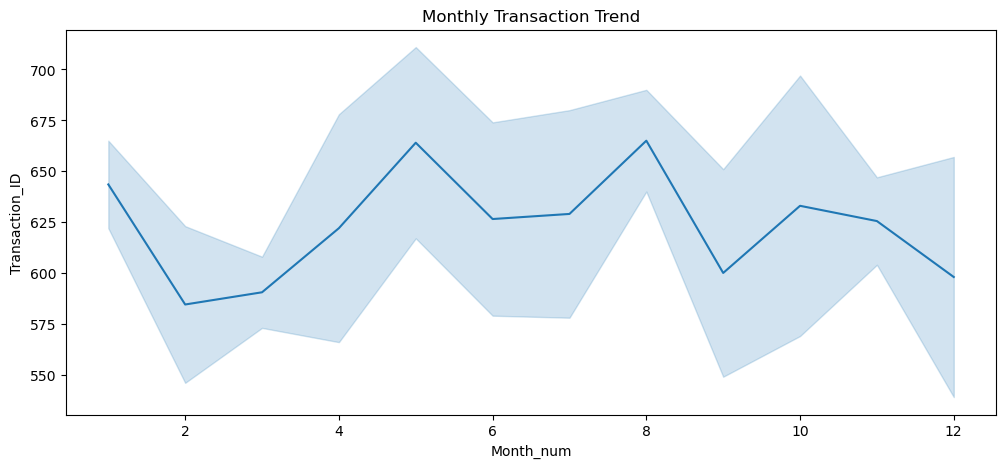

In [48]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=monthly_tren,
    x='Month_num',
    y='Transaction_ID'
)

plt.title('Monthly Transaction Trend')
plt.show()

##### 2. Hari dengan penjualan paling ramai

In [51]:
day_sales = (
    df_clean.groupby('Day_name')
    ['Transaction_ID']
    .nunique()
    .reset_index()
)

<Axes: xlabel='Day_name', ylabel='Transaction_ID'>

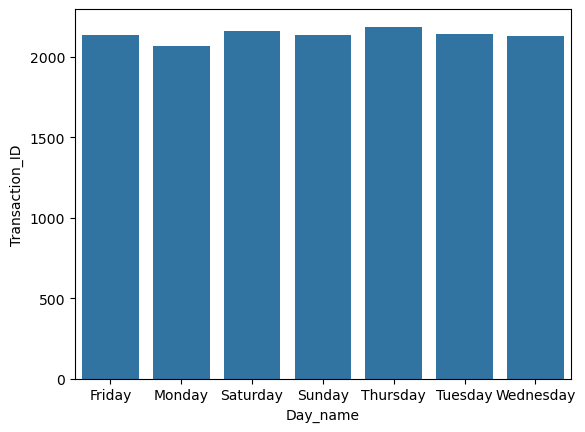

In [52]:
sns.barplot(
    data=day_sales,
    x='Day_name',
    y='Transaction_ID'
)

##### 3. Bulan vs Jumlah transaksi

In [60]:
monthly_trx = (
    df_clean.groupby(
        ['Month_num','Month']
    )['Transaction_ID']
    .nunique()
    .reset_index()
)

monthly_trx = monthly_trx.sort_values(
    'Month_num'
)
monthly_trx

,Month_num,Month,Transaction_ID
0,1,January,1287
1,2,February,1169
2,3,March,1181
3,4,April,1244
4,5,May,1328
5,6,June,1253
6,7,July,1258
7,8,August,1330
8,9,September,1200
9,10,October,1266


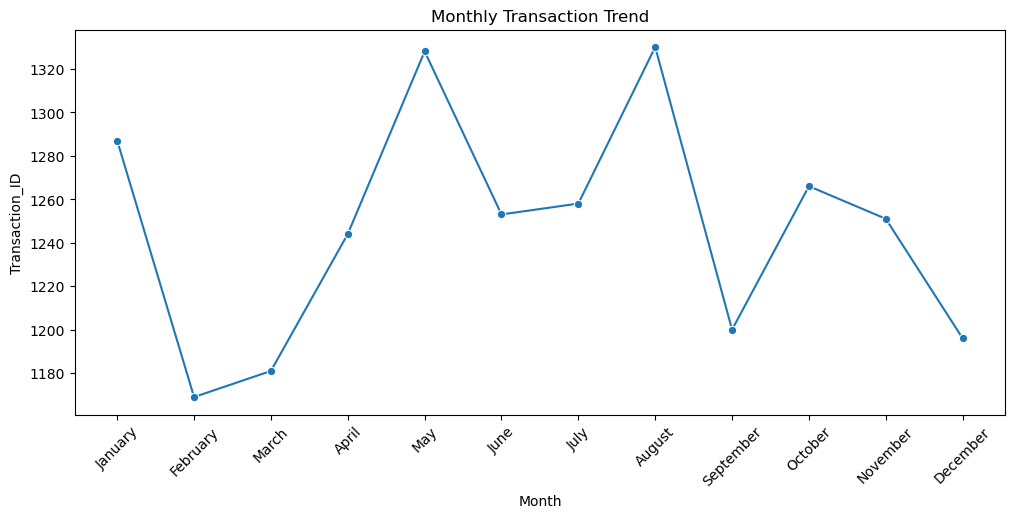

In [59]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=monthly_trx,
    x='Month',
    y='Transaction_ID',
    marker='o'
)

plt.xticks(rotation=45)

plt.title('Monthly Transaction Trend')

plt.show()

Insight :
- Terdapat fluktuasi jumlah transaksi sepanjang tahun yang dapat digunakan untuk menentukan periode promosi yang tepat
- Bulan dengan jumlah transaksi tertinggi yaitu pada bulan Mei dan Agustus

##### 4. Customer vs Frekuensi transaksi

In [63]:
customer_freq = (
    df_clean.groupby('Member_number')
    ['Transaction_ID']
    .nunique()
    .reset_index()
)

customer_freq.columns=[
    'Customer',
    'Total_Transactions'
]

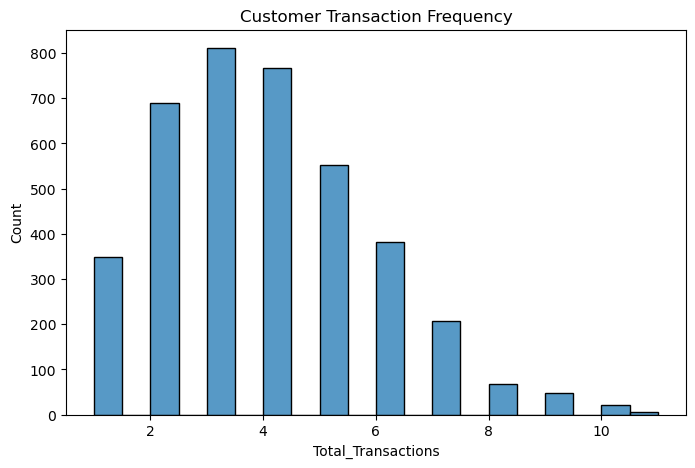

In [64]:
plt.figure(figsize=(8,5))

sns.histplot(
    customer_freq['Total_Transactions'],
    bins=20
)

plt.title('Customer Transaction Frequency')
plt.show()

Insight :
- Mayoritas pelanggan memiliki frekuensi transaksi rendah, menunjukkan peluang peningkatan loyalitas pelanggan

##### 5. Bulan vs Basket Size

In [66]:
basket_month = (
    df_clean.groupby('Month')
    ['Basket_size']
    .mean()
    .reset_index()
)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'April'),
  Text(1, 0, 'August'),
  Text(2, 0, 'December'),
  Text(3, 0, 'February'),
  Text(4, 0, 'January'),
  Text(5, 0, 'July'),
  Text(6, 0, 'June'),
  Text(7, 0, 'March'),
  Text(8, 0, 'May'),
  Text(9, 0, 'November'),
  Text(10, 0, 'October'),
  Text(11, 0, 'September')])

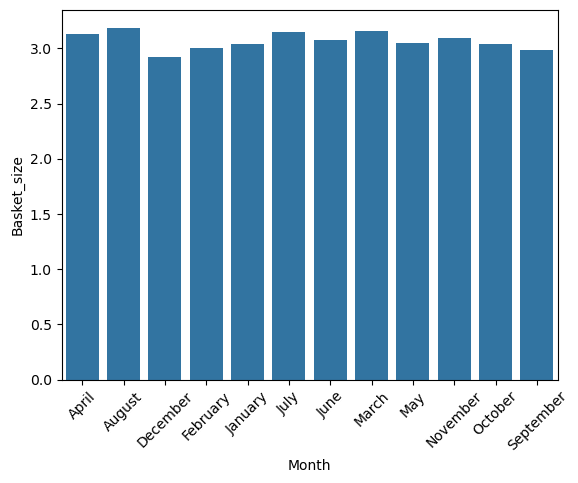

In [67]:
sns.barplot(
    data=basket_month,
    x='Month',
    y='Basket_size'
)

plt.xticks(rotation=45)

Insight :
- Pada bulan agustus pelanggan cenderung membeli lebih banyak produk dalam satu transaksi.

##### MULTIVARIATE

##### 1. Top produk per month

In [68]:
top10_product = (
    df_clean['Item_description']
    .value_counts()
    .head(10)
    .index
)

heatmap_data = pd.crosstab(
    df_clean['Month'],
    df_clean['Item_description']
)

heatmap_data = heatmap_data[
    top10_product
]

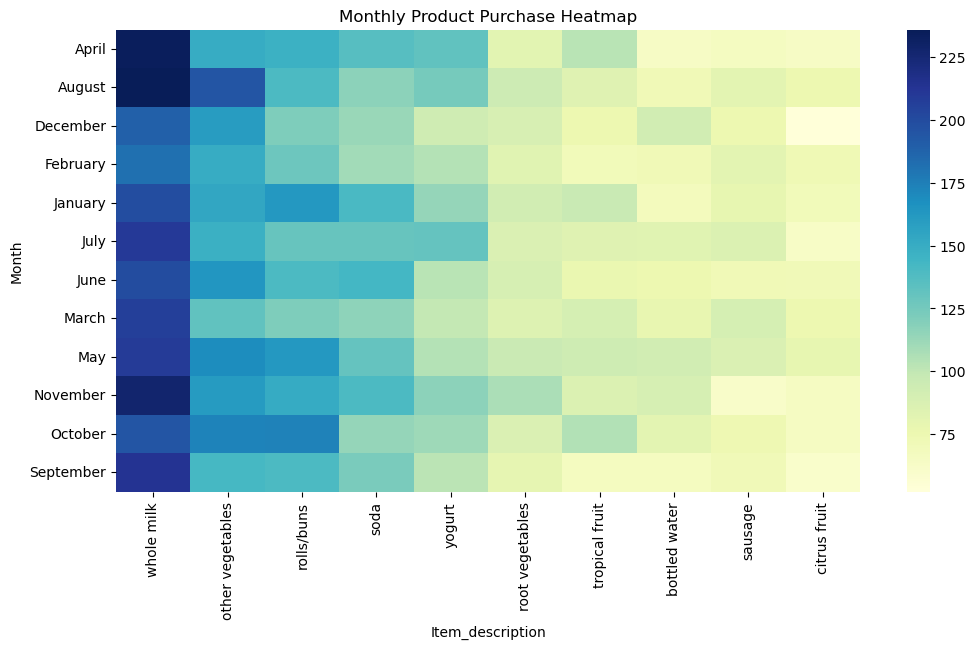

In [69]:
plt.figure(figsize=(12,6))

sns.heatmap(
    heatmap_data,
    cmap='YlGnBu'
)

plt.title(
    'Monthly Product Purchase Heatmap'
)

plt.show()

### 6. Market Basket Analysis

#### STEP 1-Market Basket Analysis

##### 1. Membuat transaction list

In [84]:
transactions = (
    df_clean.groupby('Transaction_ID')
    ['Item_description']
    .apply(list)
    .tolist()
)
transactions[:5]

[['whole milk', 'pastry', 'salty snack'],
 ['sausage', 'whole milk', 'semi-finished bread', 'yogurt'],
 ['soda', 'pickled vegetables'],
 ['canned beer', 'misc. beverages'],
 ['sausage', 'hygiene articles']]

##### 2. One-hot encoding

In [87]:
from mlxtend.preprocessing import TransactionEncoder
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
basket = pd.DataFrame(
    te_array,
    columns=te.columns_
)

basket.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


##### 3. Apriori

In [89]:
from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(
    basket,
    min_support=0.01,
    use_colnames=True
)

frequent_itemsets.sort_values(
    by='support',
    ascending=False
).head(10)

,support,itemsets
62,0.157923,(whole milk)
40,0.122101,(other vegetables)
46,0.110005,(rolls/buns)
52,0.097106,(soda)
63,0.085879,(yogurt)
47,0.069572,(root vegetables)
57,0.067767,(tropical fruit)
5,0.060683,(bottled water)
49,0.060349,(sausage)
15,0.053131,(citrus fruit)


#### STEP 2-Analisis Support

##### 1. Top 10 itemset

In [91]:
top_support = (
    frequent_itemsets
    .sort_values(
        by='support',
        ascending=False
    )
    .head(10)
)

top_support

,support,itemsets
62,0.157923,(whole milk)
40,0.122101,(other vegetables)
46,0.110005,(rolls/buns)
52,0.097106,(soda)
63,0.085879,(yogurt)
47,0.069572,(root vegetables)
57,0.067767,(tropical fruit)
5,0.060683,(bottled water)
49,0.060349,(sausage)
15,0.053131,(citrus fruit)


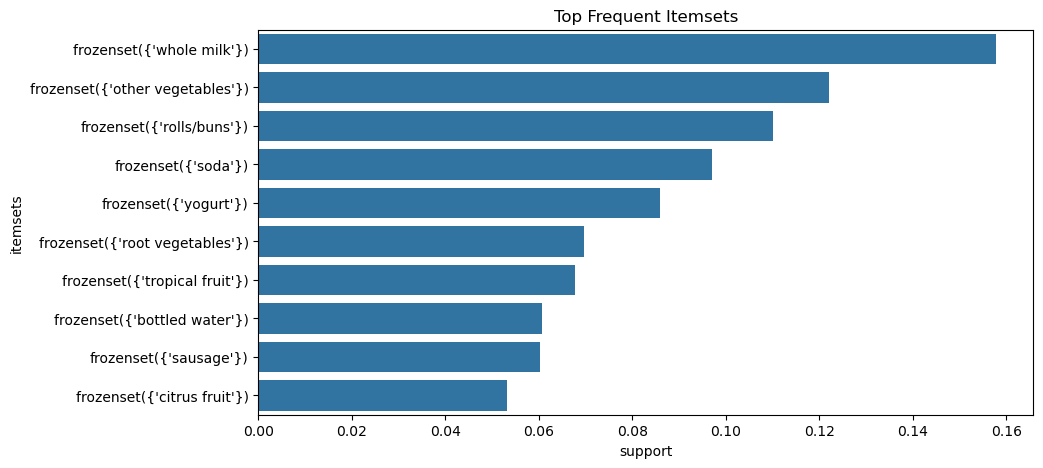

In [93]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=top_support,
    x='support',
    y=top_support['itemsets'].astype(str)
)

plt.title('Top Frequent Itemsets')
plt.show()

#### STEP 3-Asociaton Rules

In [114]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_itemsets,
    metric='lift',
    min_threshold=1.0
)

In [115]:
rules_filtered = rules[
    (rules['confidence'] >= 0.20)
    &
    (rules['lift'] >= 1)
].copy()

In [116]:
top_rules = (
    rules_filtered
    .sort_values(
        by='lift',
        ascending=False
    )
)

top_rules.head(20)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


In [113]:
top_lift = (
    top_rules[
        [
            'antecedents',
            'consequents',
            'support',
            'confidence',
            'lift'
        ]
    ]
    .head(10)
)

top_lift

,antecedents,consequents,support,confidence,lift


In [117]:
rules.shape

(0, 14)

INTERPRETASI :
- artinya tidak ada association rule yang memenuhi syarat

In [129]:
# print(frequent_itemsets.sort_values(
#     by='support',
#     ascending=False
# ))

# frequent_itemsets.head(20)

frequent_itemsets.sort_values(
    by='support',
    ascending=False
).head(10)

,support,itemsets,length
62,0.157923,(whole milk),1
40,0.122101,(other vegetables),1
46,0.110005,(rolls/buns),1
52,0.097106,(soda),1
63,0.085879,(yogurt),1
47,0.069572,(root vegetables),1
57,0.067767,(tropical fruit),1
5,0.060683,(bottled water),1
49,0.060349,(sausage),1
15,0.053131,(citrus fruit),1


In [119]:
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

frequent_itemsets['length'].value_counts()

length
1    64
2     5
Name: count, dtype: int64

INTERPRETASI :
- Terdapat 64 itemset berisi 1 produk 
- Terdapat 5 itemset berisi 2 produk

In [121]:
pair_itemsets = (
    frequent_itemsets[
        frequent_itemsets['length'] == 2
    ]
    .sort_values(
        by='support',
        ascending=False
    )
)

pair_itemsets

,support,itemsets,length
65,0.014837,"(other vegetables, whole milk)",2
66,0.013968,"(whole milk, rolls/buns)",2
67,0.011629,"(whole milk, soda)",2
68,0.011161,"(yogurt, whole milk)",2
64,0.010559,"(other vegetables, rolls/buns)",2


INTERPRETASI :
- Whole milk adalah produk ini berdasarkan data nilai suppport yang muncul karena whole milk muncul di 4 dari 5 kombinasi teratas

In [146]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.12
)

print(rules.shape)

(3, 14)


- Persentase maksimal untuk min_threshold confidence adalah 12%, kalau diatas 12% maka tidak ada kombinasi yang bisa dijadikan untuk bundling

In [147]:
rules[
    [
        'antecedents',
        'consequents',
        'support',
        'confidence',
        'lift'
    ]
].sort_values(
    by='lift',
    ascending=False
)

,antecedents,consequents,support,confidence,lift
2,(yogurt),(whole milk),0.011161,0.129961,0.822940
1,(rolls/buns),(whole milk),0.013968,0.126974,0.804028
0,(other vegetables),(whole milk),0.014837,0.121511,0.769430


INTERPRETASI :
- Data teratas menunjukkan kombinasi yogurt dan whole milk dengan nilai support 0.0112 atau 1.12% transaksi yang membeli yogurt dan whole milk secara bersamaan
- Nilai confidance 0.13 yang menyatakan dari selurih pelanggan yang membeli yoghurt hanya sekitar 13% yang juga membeli whole milk
- Nilai lift 0.82 yaitu lift < 1 maka pembelian yogurt justru tidak meningkatkan kemungkinan pembelian whole milk.
- Secara keseluruhan ini menunjukkan hubungannya lemah

##### INSIGHT

1. Whole milk merupakan produk yang paling sering muncul dalam kombinasi pembelian pelanggan
2. Kombinasi paling sering dibeli bersama adalah other vegetables dengan whole milk dengan support 1.48%
3. Meskipun terdapat beberapa kombinasi produk yang sering muncul, seluruh nilai lift masih berada dibawah 1 sehingga hubungan antar produk tergolong lemah dan belum menunjukkan asosiasi pembelian yang kuat
4. Produk whole milk dianggap menjadi produk pusat karena muncul pada sebagian besar kombinasi itemset teratas

##### Rekomendasi

1. Melakukan bundling Whole milk dengan other vegetables karena kombinasi ini paling sering muncul
2. Melakukan cross-selling, saat pelanggan membeli whole milk sistem dapat merekomendasikan rolls/buns, yogurt, other vegetables
3. Menyusun penataan rak dengan menyusun produk-produk berikut ditempatkan berdekatan yaitu whole milk, other vegetables, rolls/buns, yogurt untuk meningkatkan peluang pembelian bersama

##### Export dataset final dari python

##### Dataset 1 : Data Utama

In [124]:
df_clean.to_csv('Market_Basket_Analysis_Clean.csv', index=False)

In [125]:
df_clean.head()

,Member_number,Date,Item_description,Year,Month,Month_num,Quarter,Day_name,Transaction_ID,Basket_size
0,1808,2015-07-21,tropical fruit,2015,July,7,3,Tuesday,1808_2015-07-21,3
1,2552,2015-01-05,whole milk,2015,January,1,1,Monday,2552_2015-01-05,3
2,2300,2015-09-19,pip fruit,2015,September,9,3,Saturday,2300_2015-09-19,3
3,1187,2015-12-12,other vegetables,2015,December,12,4,Saturday,1187_2015-12-12,3
4,3037,2015-02-01,whole milk,2015,February,2,1,Sunday,3037_2015-02-01,3


##### Dataset 2 : MBA Result

In [126]:
mba_result = rules.copy()

mba_result['antecedents'] = (
    mba_result['antecedents']
    .astype(str)
)

mba_result['consequents'] = (
    mba_result['consequents']
    .astype(str)
)

mba_result.to_csv(
    'mba_result.csv',
    index=False
)